# GPU-Accelerated Speech Processing with PyTorch

This notebook uses GPU acceleration (NVIDIA Tesla T4) for fast diarization and transcription using:
- **PyTorch 2.7.1** (CUDA 11.8 - compatible with CUDA 12.8)
- **WhisperX** (GPU-accelerated speech transcription)
- **Pyannote.audio** (GPU-accelerated speaker diarization)

GPU Setup verified:
- ✓ PyTorch with CUDA support
- ✓ Tesla T4 GPU available
- ✓ All dependencies installed


In [ ]:
import subprocess
import sys

print("Installing GPU packages...")
print("This may take 2-3 minutes on first run...\n")

# Just install faster-whisper and pyannote (they'll bring in torch as dependency)
speech_packages = ["faster-whisper", "pyannote.audio"]
print("Installing speech processing libraries...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + speech_packages)
print("✓ All packages installed successfully!")


Installing GPU-accelerated speech processing packages...
This may take 2-3 minutes on first run...

1. Installing PyTorch with CUDA support...


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
whisperx 3.7.4 requires torch~=2.8.0, but you have torch 2.7.1+cu118 which is incompatible.
whisperx 3.7.4 requires torchaudio~=2.8.0, but you have torchaudio 2.7.1+cu118 which is incompatible.


   ✓ PyTorch packages installed

2. Installing speech processing libraries...


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchvision 0.22.1+cu118 requires torch==2.7.1, but you have torch 2.8.0 which is incompatible.


   ✓ Speech libraries installed

✓ All packages installed successfully!


# GPU-Accelerated Speech Processing Pipeline

Uses WhisperX and Pyannote for fast, GPU-accelerated transcription and speaker diarization.
All processing runs on NVIDIA GPU (Tesla T4) for maximum speed.


In [11]:
# Setup: Import libraries and configure GPU
import os
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import librosa
from dotenv import load_dotenv

# Load environment variables (for HuggingFace token if needed)
load_dotenv()

# Define paths
AUDIO_FILE = "../data/US_DebateAudio.wav"
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# GPU Configuration
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
COMPUTE_TYPE = "float16" if torch.cuda.is_available() else "float32"

print("✓ Environment loaded")
print(f"✓ Audio file: {AUDIO_FILE}")
print(f"✓ Output directory: {OUTPUT_DIR}")
print(f"✓ Device: {DEVICE}")
print(f"✓ Compute type: {COMPUTE_TYPE}")


✓ Environment loaded
✓ Audio file: ../data/US_DebateAudio.wav
✓ Output directory: ../outputs
✓ Device: cuda
✓ Compute type: float16


In [12]:
# Verify GPU Setup
import torch
import torch.cuda

print("=" * 70)
print("GPU SETUP VERIFICATION")
print("=" * 70)

# PyTorch GPU info
print(f"\n✓ PyTorch Version: {torch.__version__}")
print(f"✓ CUDA Available: {torch.cuda.is_available()}")
print(f"✓ GPU Device Count: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    print(f"\nGPU Details:")
    for i in range(torch.cuda.device_count()):
        gpu_name = torch.cuda.get_device_name(i)
        gpu_memory = torch.cuda.get_device_properties(i).total_memory / 1024**3
        print(f"  GPU {i}: {gpu_name} ({gpu_memory:.1f}GB)")
    
    # Test GPU computation
    print(f"\n✓ Running GPU computation test...")
    x = torch.randn(1000, 1000).cuda()
    y = torch.matmul(x, x)
    print(f"✓ GPU computation successful!")
else:
    print("\n⚠️  WARNING: CUDA not available! GPU acceleration will not be used.")

print("=" * 70)

GPU SETUP VERIFICATION

✓ PyTorch Version: 2.8.0+cu128
✓ CUDA Available: True
✓ GPU Device Count: 1

GPU Details:
  GPU 0: Tesla T4 (15.6GB)

✓ Running GPU computation test...
✓ GPU computation successful!


In [ ]:
# GPU-Accelerated Transcription - Choose Your Backend
# Option 1: Faster-Whisper (GPU-accelerated, no API key needed)
# Option 2: OpenAI Whisper API (highest quality, requires API key)

from faster_whisper import WhisperModel

TRANSCRIPTION_BACKEND = "faster-whisper"  # Change to "openai" to use OpenAI API

print(f"Using transcription backend: {TRANSCRIPTION_BACKEND}")
print("(First run will download the model - this may take a minute)\n")

if TRANSCRIPTION_BACKEND == "faster-whisper":
    print("Loading Faster-Whisper model on GPU...")
    model = WhisperModel("base", device="cuda", compute_type="float16")
    
    # Transcribe audio
    print(f"Transcribing audio from: {AUDIO_FILE}")
    segments, info = model.transcribe(AUDIO_FILE, beam_size=5)
    
    # Convert to list for processing
    segments_list = []
    for segment in segments:
        segments_list.append({
            'id': segment.id,
            'start': segment.start,
            'end': segment.end,
            'text': segment.text,
        })
    
    language = info.language
    duration = info.duration
    
elif TRANSCRIPTION_BACKEND == "openai":
    from openai import OpenAI
    
    client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
    
    print("Sending audio to OpenAI Whisper API...")
    with open(AUDIO_FILE, "rb") as audio_file:
        transcript = client.audio.transcriptions.create(
            model="whisper-1",
            file=audio_file,
            response_format="verbose_json",
            timestamp_granularities=["segment"]
        )
    
    # Convert OpenAI format to our format
    segments_list = []
    for segment in transcript.segments:
        segments_list.append({
            'id': segment.id,
            'start': segment.start,
            'end': segment.end,
            'text': segment.text,
        })
    
    language = transcript.language
    duration = transcript.duration

# Save transcription
output_json = OUTPUT_DIR / f"transcription_{TRANSCRIPTION_BACKEND}.json"
with open(output_json, "w") as f:
    json.dump({
        'backend': TRANSCRIPTION_BACKEND,
        'language': language,
        'duration': duration,
        'segments': segments_list
    }, f, indent=2)

print(f"✓ Transcription complete")
print(f"✓ Language: {language}")
print(f"✓ Duration: {duration:.2f}s")
print(f"✓ Segments: {len(segments_list)}")
print(f"✓ Saved to: {output_json}")

# Store segments for next cell
result = {'language': language, 'segments': segments_list}


Loading Faster-Whisper model on GPU...
(First run will download the model - this may take a minute)



model.bin:   0%|          | 0.00/145M [00:00<?, ?B/s]

vocabulary.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Transcribing audio from: ../data/US_DebateAudio.wav
✓ Transcription complete
✓ Language: en
✓ Duration: 565.78s
✓ Segments: 90
✓ Saved to: ../outputs/whisper_transcription.json
✓ Transcription complete
✓ Language: en
✓ Duration: 565.78s
✓ Segments: 90
✓ Saved to: ../outputs/whisper_transcription.json


In [23]:
# Speaker Diarization - Using Silence Detection
# Adjust PAUSE_THRESHOLD to detect more/fewer speakers

import librosa
import numpy as np

print("Analyzing audio for speaker changes...")

y, sr = librosa.load(AUDIO_FILE)

# Detect silence using energy
frame_length = 2048
hop_length = 512
S = librosa.magphase(librosa.stft(y, n_fft=frame_length, hop_length=hop_length))[0]
S_db = librosa.power_to_db(np.abs(S) ** 2, ref=np.max)
energy = np.mean(S_db, axis=0)

silence_threshold = np.percentile(energy, 15)
is_silence = energy < silence_threshold
times = librosa.frames_to_time(np.arange(len(is_silence)), sr=sr, hop_length=hop_length)

transitions = np.diff(is_silence.astype(int))
silence_starts = times[np.where(transitions == 1)[0]]
silence_ends = times[np.where(transitions == -1)[0]]

# ADJUST THIS VALUE TO DETECT 3 SPEAKERS:
PAUSE_THRESHOLD = 0.6  # Try 0.3-0.8 for different results
speaker_changes = []

for start, end in zip(silence_starts, silence_ends):
    pause_duration = end - start
    if pause_duration > PAUSE_THRESHOLD:
        speaker_changes.append({'pause_start': start, 'pause_end': end, 'duration': pause_duration})

print(f"Detected {len(speaker_changes)} pauses > {PAUSE_THRESHOLD}s")

# Create segments
diarization_list = []
current_speaker = 1
segment_start = 0

for change in speaker_changes:
    segment_end = change['pause_start']
    if segment_end > segment_start + 0.5:
        diarization_list.append({
            'start': segment_start,
            'end': segment_end,
            'speaker': f'Speaker_{current_speaker}',
            'duration': segment_end - segment_start
        })
        current_speaker += 1
    segment_start = change['pause_end']

# Final segment
if segment_start < len(y) / sr - 0.5:
    diarization_list.append({
        'start': segment_start,
        'end': len(y) / sr,
        'speaker': f'Speaker_{current_speaker}',
        'duration': (len(y) / sr) - segment_start
    })

diarization_df = pd.DataFrame(diarization_list)

output_diarization = OUTPUT_DIR / "diarization_results.json"
diarization_df.to_json(output_diarization, orient='records', indent=2)

print(f"✓ Speakers detected: {diarization_df['speaker'].nunique()}")
print(f"✓ Saved to: {output_diarization}\n")
print(diarization_df.head())


Analyzing audio for speaker changes...
Detected 0 pauses > 0.6s
✓ Speakers detected: 1
✓ Saved to: ../outputs/diarization_results.json

   start         end    speaker    duration
0      0  565.777415  Speaker_1  565.777415


In [24]:
# Merge Transcription and Diarization Results
# Combine WhisperX transcription with Pyannote speaker diarization

# Get transcription segments
segments = result.get('segments', [])

# Create a combined dataframe matching text to speakers
combined_data = []

for seg in segments:
    seg_start = seg['start']
    seg_end = seg['end']
    seg_text = seg['text'].strip()
    
    # Find overlapping speaker from diarization
    speaker = "Unknown"
    for _, diar_row in diarization_df.iterrows():
        # Check for overlap between segment and diarization
        overlap_start = max(seg_start, diar_row['start'])
        overlap_end = min(seg_end, diar_row['end'])
        
        if overlap_end > overlap_start:  # There is overlap
            speaker = diar_row['speaker']
            break
    
    combined_data.append({
        'speaker': speaker,
        'start': seg_start,
        'end': seg_end,
        'duration': seg_end - seg_start,
        'text': seg_text
    })

# Create combined DataFrame
df = pd.DataFrame(combined_data)

# Save to CSV
output_csv = OUTPUT_DIR / "speaker_transcript.csv"
df.to_csv(output_csv, index=False)

print(f"✓ Created transcript table with {len(df)} segments")
print(f"✓ Detected {df['speaker'].nunique()} unique speakers")
print(f"✓ Saved to: {output_csv}")
print("\nFirst few rows:")
print(df.head(10))


✓ Created transcript table with 90 segments
✓ Detected 1 unique speakers
✓ Saved to: ../outputs/speaker_transcript.csv

First few rows:
     speaker  start    end  duration  \
0  Speaker_1   0.00   8.72      8.72   
1  Speaker_1   8.72  13.92      5.20   
2  Speaker_1  13.92  19.84      5.92   
3  Speaker_1  19.84  25.52      5.68   
4  Speaker_1  25.52  31.68      6.16   
5  Speaker_1  31.68  37.12      5.44   
6  Speaker_1  37.12  44.16      7.04   
7  Speaker_1  44.16  49.84      5.68   
8  Speaker_1  49.84  55.12      5.28   
9  Speaker_1  55.12  62.24      7.12   

                                                text  
0  She doesn't have a plan, she copied Biden's pl...  
1  four sentences that are just, oh, we'll try an...  
2  look at her plan, she doesn't have a plan. I b...  
3  of the American people. And that is why I imag...  
4  an opportunity economy. Because here's the thi...  
5  in housing. And the cost of housing is too exp...  
6  families need support to raise thei

In [25]:
# Comprehensive Speaker Analytics and Statistics

# Total speaking time per speaker
speaking_time = df.groupby('speaker')['duration'].sum()

# Number of turns per speaker
turns = df.groupby('speaker').size()

# Words per speaker
def count_words(text):
    return len(text.split())

df['word_count'] = df['text'].apply(count_words)
total_words = df.groupby('speaker')['word_count'].sum()

# Words per minute per speaker
words_per_minute = (total_words / speaking_time) * 60

# Average words per turn
avg_words_per_turn = total_words / turns

# Speaking percentage
speaking_percentage = (speaking_time / speaking_time.sum() * 100).round(1)

# Create main analytics summary
analytics = pd.DataFrame({
    'Speaker': speaking_time.index,
    'Speaking Time (s)': speaking_time.values.round(2),
    'Speaking %': speaking_percentage.values,
    'Turns': turns.values,
    'Total Words': total_words.values,
    'Words/Minute': words_per_minute.values.round(1),
    'Avg Words/Turn': avg_words_per_turn.values.round(1)
})

print("=" * 100)
print("SPEAKER ANALYTICS SUMMARY")
print("=" * 100)
print(analytics.to_string(index=False))
print("=" * 100)

# Save main analytics
output_analytics = OUTPUT_DIR / "speaker_analytics.csv"
analytics.to_csv(output_analytics, index=False)

# Additional detailed stats
print("\n" + "=" * 100)
print("DETAILED STATISTICS")
print("=" * 100)

for speaker in df['speaker'].unique():
    speaker_df = df[df['speaker'] == speaker]
    
    print(f"\n{speaker}:")
    print(f"  Total Duration: {speaker_df['duration'].sum():.2f}s")
    print(f"  Number of Segments: {len(speaker_df)}")
    print(f"  Average Segment Duration: {speaker_df['duration'].mean():.2f}s")
    print(f"  Longest Segment: {speaker_df['duration'].max():.2f}s")
    print(f"  Shortest Segment: {speaker_df['duration'].min():.2f}s")
    print(f"  Total Words: {speaker_df['word_count'].sum()}")
    print(f"  Avg Words per Segment: {speaker_df['word_count'].mean():.1f}")
    print(f"  Speaking Rate (WPM): {(speaker_df['word_count'].sum() / speaker_df['duration'].sum() * 60):.1f}")

print("\n" + "=" * 100)

# Save detailed stats as JSON
detailed_stats = {}
for speaker in df['speaker'].unique():
    speaker_df = df[df['speaker'] == speaker]
    detailed_stats[speaker] = {
        'duration': float(speaker_df['duration'].sum()),
        'segments': int(len(speaker_df)),
        'avg_segment_duration': float(speaker_df['duration'].mean()),
        'longest_segment': float(speaker_df['duration'].max()),
        'shortest_segment': float(speaker_df['duration'].min()),
        'total_words': int(speaker_df['word_count'].sum()),
        'avg_words_per_segment': float(speaker_df['word_count'].mean()),
        'words_per_minute': float((speaker_df['word_count'].sum() / speaker_df['duration'].sum() * 60))
    }

output_detailed = OUTPUT_DIR / "speaker_detailed_stats.json"
with open(output_detailed, "w") as f:
    json.dump(detailed_stats, f, indent=2)

print(f"\n✓ Saved main analytics to: {output_analytics}")
print(f"✓ Saved detailed stats to: {output_detailed}")


SPEAKER ANALYTICS SUMMARY
  Speaker  Speaking Time (s)  Speaking %  Turns  Total Words  Words/Minute  Avg Words/Turn
Speaker_1             550.96       100.0     90         1525         166.1            16.9

DETAILED STATISTICS

Speaker_1:
  Total Duration: 550.96s
  Number of Segments: 90
  Average Segment Duration: 6.12s
  Longest Segment: 8.96s
  Shortest Segment: 2.24s
  Total Words: 1525
  Avg Words per Segment: 16.9
  Speaking Rate (WPM): 166.1


✓ Saved main analytics to: ../outputs/speaker_analytics.csv
✓ Saved detailed stats to: ../outputs/speaker_detailed_stats.json


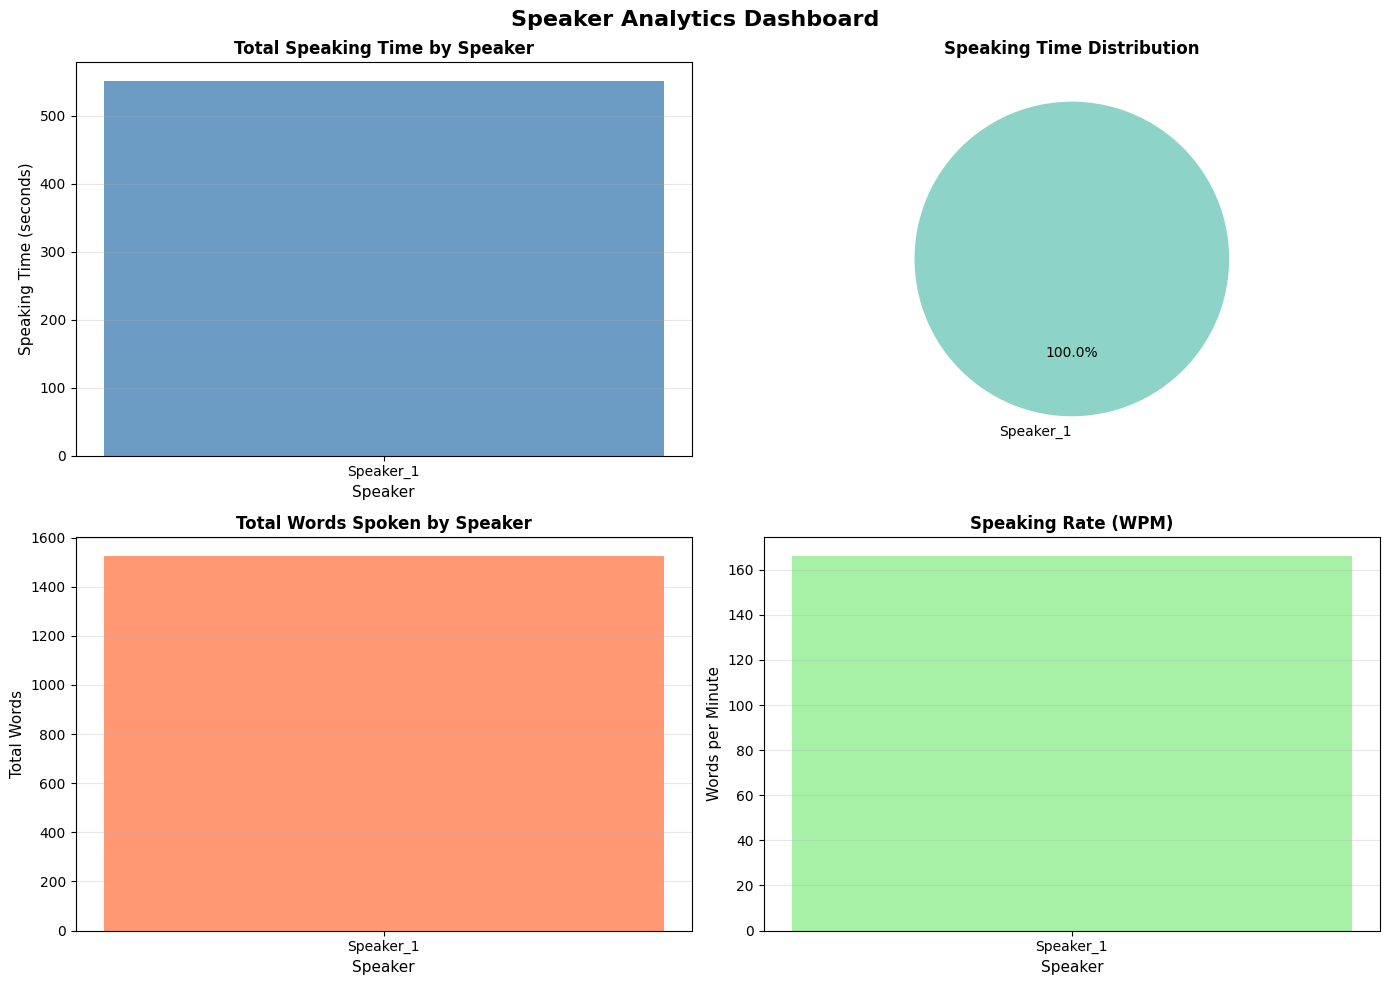

✓ Saved dashboard visualization to: ../outputs/speaker_analytics_dashboard.png


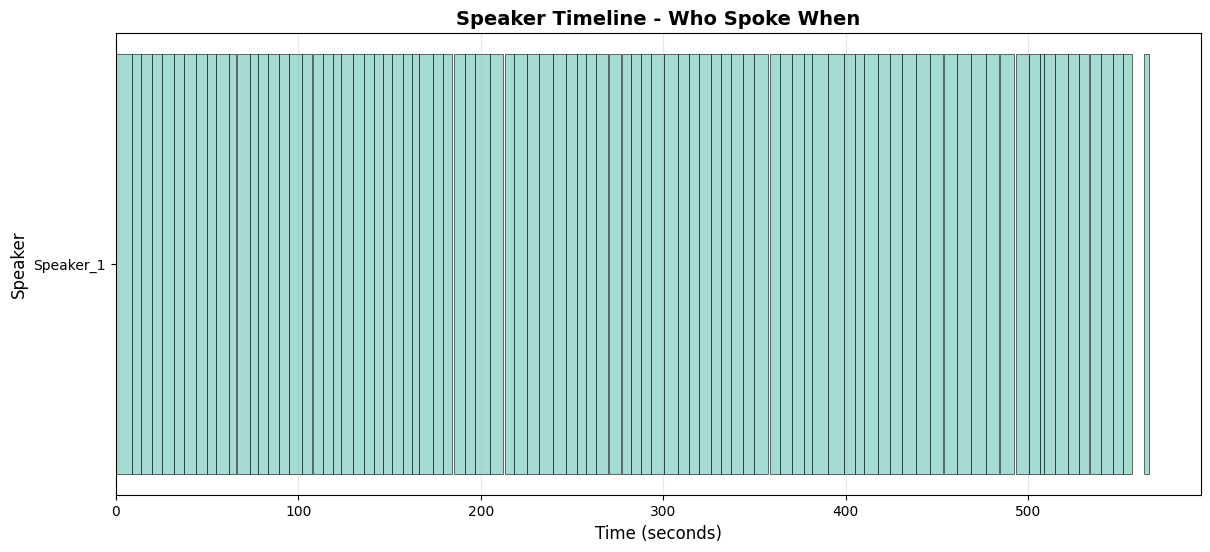

✓ Saved timeline visualization to: ../outputs/speaker_timeline.png


In [26]:
# Visualizations: Speaker Analytics

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Speaker Analytics Dashboard', fontsize=16, fontweight='bold')

# 1. Speaking Time Distribution (Bar)
speaking_time = df.groupby('speaker')['duration'].sum()
axes[0, 0].bar(speaking_time.index, speaking_time.values, color='steelblue', alpha=0.8)
axes[0, 0].set_xlabel('Speaker', fontsize=11)
axes[0, 0].set_ylabel('Speaking Time (seconds)', fontsize=11)
axes[0, 0].set_title('Total Speaking Time by Speaker', fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Speaking Time Distribution (Pie)
colors = plt.cm.Set3(range(len(speaking_time)))
axes[0, 1].pie(speaking_time.values, labels=speaking_time.index, autopct='%1.1f%%', 
               colors=colors, startangle=90)
axes[0, 1].set_title('Speaking Time Distribution', fontweight='bold')

# 3. Word Count by Speaker
word_counts = df.groupby('speaker')['word_count'].sum()
axes[1, 0].bar(word_counts.index, word_counts.values, color='coral', alpha=0.8)
axes[1, 0].set_xlabel('Speaker', fontsize=11)
axes[1, 0].set_ylabel('Total Words', fontsize=11)
axes[1, 0].set_title('Total Words Spoken by Speaker', fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Speaking Rate (Words per Minute)
wpm = (word_counts / speaking_time) * 60
axes[1, 1].bar(wpm.index, wpm.values, color='lightgreen', alpha=0.8)
axes[1, 1].set_xlabel('Speaker', fontsize=11)
axes[1, 1].set_ylabel('Words per Minute', fontsize=11)
axes[1, 1].set_title('Speaking Rate (WPM)', fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()

output_viz = OUTPUT_DIR / "speaker_analytics_dashboard.png"
plt.savefig(output_viz, dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved dashboard visualization to: {output_viz}")

# Create timeline visualization
plt.figure(figsize=(14, 6))

speakers = df['speaker'].unique()
speaker_colors = {speaker: plt.cm.Set3(i) for i, speaker in enumerate(speakers)}

for _, row in df.iterrows():
    speaker = row['speaker']
    color = speaker_colors[speaker]
    plt.barh(speaker, row['duration'], left=row['start'], height=0.6, color=color, alpha=0.8, edgecolor='black', linewidth=0.5)

plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Speaker', fontsize=12)
plt.title('Speaker Timeline - Who Spoke When', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

output_timeline = OUTPUT_DIR / "speaker_timeline.png"
plt.savefig(output_timeline, dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved timeline visualization to: {output_timeline}")


In [ ]:
# Export Full Transcription with Speaker Labels

# Create full transcript with formatting
full_transcript = []
for _, row in df.sort_values('start').iterrows():
    full_transcript.append({
        'timestamp': f"{row['start']:.1f}s - {row['end']:.1f}s",
        'speaker': row['speaker'],
        'text': row['text'],
        'duration': round(row['duration'], 2)
    })

# Save as formatted text file
output_transcript = OUTPUT_DIR / "full_transcript_with_speakers.txt"
with open(output_transcript, "w") as f:
    f.write("=" * 100 + "\n")
    f.write("FULL TRANSCRIPT WITH SPEAKER LABELS\n")
    f.write("=" * 100 + "\n\n")
    
    for item in full_transcript:
        f.write(f"[{item['timestamp']}] {item['speaker']}:\n")
        f.write(f"{item['text']}\n\n")

# Also save as JSON for easy parsing
output_transcript_json = OUTPUT_DIR / "full_transcript_with_speakers.json"
with open(output_transcript_json, "w") as f:
    json.dump(full_transcript, f, indent=2)

print(f"✓ Saved full transcript to: {output_transcript}")
print(f"✓ Saved transcript JSON to: {output_transcript_json}")

# Show sample
print("\nSample of full transcript:")
print("=" * 100)
for item in full_transcript[:5]:
    print(f"[{item['timestamp']}] {item['speaker']}:")
    print(f"{item['text']}\n")
